# Visual priors serial reproduction simulation analysis

This notebook reads the simulated PsyNet export directly and summarizes whether the chain implementation produced the expected serial reproduction data.

In [1]:
from pathlib import Path
import zipfile

import pandas as pd

zip_path = Path('../simulated_data.zip')
with zipfile.ZipFile(zip_path) as z:
    with z.open('data/simulated_data/regular/data/SpatialMemoryTrial.csv') as f:
        trials = pd.read_csv(f)

columns = [
    'shape', 'shape_label', 'chain_id', 'generation', 'target_x', 'target_y',
    'response_x', 'response_y', 'euclidean_error', 'accurate'
]
trials = trials[columns].sort_values(['shape', 'chain_id', 'generation']).reset_index(drop=True)
trials.head()

shape,shape_label,chain_id,generation,target_x,target_y,response_x,response_y,euclidean_error,accurate
circle,circle,circle-1,0,0.7088,0.7937,0.7177,0.7424,0.0521,True
circle,circle,circle-1,1,0.7177,0.7424,0.6893,0.7252,0.0332,True
circle,circle,circle-1,2,0.6893,0.7252,0.7057,0.7720,0.0496,True
circle,circle,circle-1,3,0.7057,0.7720,0.7314,0.7680,0.0260,True
circle,circle,circle-1,4,0.7314,0.7680,0.7179,0.7926,0.0281,True


In [2]:
summary = (
    trials.groupby('shape_label')
    .agg(
        chains=('chain_id', 'nunique'),
        trials=('chain_id', 'size'),
        mean_error=('euclidean_error', 'mean'),
        accuracy_rate=('accurate', 'mean'),
    )
    .reset_index()
)
summary['mean_error'] = summary['mean_error'].round(4)
summary['accuracy_rate'] = summary['accuracy_rate'].round(3)
summary

shape_label,chains,trials,mean_error,accuracy_rate
circle,2,20,0.0408,1.00
equilateral triangle,2,20,0.0424,1.00
horizontal oval,2,20,0.0386,0.95
regular pentagon,2,20,0.0425,1.00
square,2,20,0.0414,1.00
vertical oval,2,20,0.0430,1.00


In [3]:
generation_summary = (
    trials.groupby('generation')
    .agg(
        trials=('chain_id', 'size'),
        mean_error=('euclidean_error', 'mean'),
        accuracy_rate=('accurate', 'mean'),
    )
    .reset_index()
)
generation_summary['mean_error'] = generation_summary['mean_error'].round(4)
generation_summary['accuracy_rate'] = generation_summary['accuracy_rate'].round(3)
generation_summary

generation,trials,mean_error,accuracy_rate
0,12,0.0526,1.000
1,12,0.0332,1.000
2,12,0.0496,1.000
3,12,0.0260,1.000
4,12,0.0281,1.000
5,12,0.0738,0.917
6,12,0.0080,1.000
7,12,0.0743,1.000
8,12,0.0368,1.000
9,12,0.0322,1.000


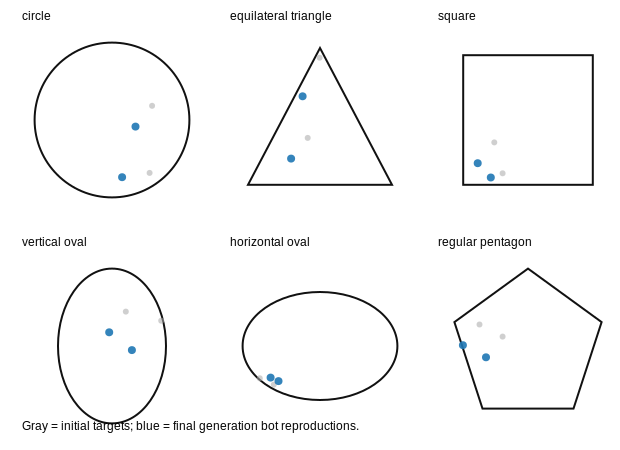

In [4]:
import math
from IPython.display import SVG, display

shape_order = ['circle', 'triangle', 'square', 'vertical_oval', 'horizontal_oval', 'pentagon']
shape_labels = dict(zip(trials['shape'], trials['shape_label']))

def outline_svg(shape, ox=0, oy=0, scale=180):
    def p(x, y):
        return f'{ox + x * scale:.1f},{oy + y * scale:.1f}'
    if shape == 'circle':
        return f'<circle cx="{ox + scale / 2:.1f}" cy="{oy + scale / 2:.1f}" r="{scale * 0.43:.1f}" />'
    if shape == 'vertical_oval':
        return f'<ellipse cx="{ox + scale / 2:.1f}" cy="{oy + scale / 2:.1f}" rx="{scale * 0.30:.1f}" ry="{scale * 0.43:.1f}" />'
    if shape == 'horizontal_oval':
        return f'<ellipse cx="{ox + scale / 2:.1f}" cy="{oy + scale / 2:.1f}" rx="{scale * 0.43:.1f}" ry="{scale * 0.30:.1f}" />'
    if shape == 'square':
        return f'<rect x="{ox + scale * 0.14:.1f}" y="{oy + scale * 0.14:.1f}" width="{scale * 0.72:.1f}" height="{scale * 0.72:.1f}" />'
    if shape == 'triangle':
        pts = ' '.join([p(0.5, 0.1), p(0.1, 0.86), p(0.9, 0.86)])
        return f'<polygon points="{pts}" />'
    pts = []
    for i in range(5):
        angle = -math.pi / 2 + 2 * math.pi * i / 5
        pts.append(p(0.5 + 0.43 * math.cos(angle), 0.5 + 0.43 * math.sin(angle)))
    return f'<polygon points="{" ".join(pts)}" />'

def scatter_svg(data):
    width, height = 620, 450
    panel = 180
    gap_x, gap_y = 28, 46
    svg = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    svg.append('<style>text{font-family:Arial,sans-serif;font-size:12px}.outline{fill:none;stroke:#111;stroke-width:2}.seed{fill:#aaa;opacity:.55}.final{fill:#1f77b4;opacity:.9}</style>')
    for idx, shape in enumerate(shape_order):
        row, col = divmod(idx, 3)
        ox = 22 + col * (panel + gap_x)
        oy = 30 + row * (panel + gap_y)
        svg.append(f'<text x="{ox}" y="{oy - 10}">{shape_labels.get(shape, shape)}</text>')
        svg.append(f'<g class="outline">{outline_svg(shape, ox, oy, panel)}</g>')
        seeds = data[(data['shape'] == shape) & (data['generation'] == 0)]
        finals = data[(data['shape'] == shape) & (data['generation'] == data['generation'].max())]
        for _, r in seeds.iterrows():
            svg.append(f'<circle class="seed" cx="{ox + r.target_x * panel:.1f}" cy="{oy + r.target_y * panel:.1f}" r="3" />')
        for _, r in finals.iterrows():
            svg.append(f'<circle class="final" cx="{ox + r.response_x * panel:.1f}" cy="{oy + r.response_y * panel:.1f}" r="4" />')
    svg.append('<text x="22" y="430">Gray = initial targets; blue = final generation bot reproductions.</text>')
    svg.append('</svg>')
    return ''.join(svg)

display(SVG(scatter_svg(trials)))

## Interpretation

The simulated export contains 120 completed `SpatialMemoryTrial` rows: 6 shapes x 2 chains per shape x 10 generations. Every generation has 12 trials, showing that responses were propagated through the chain architecture rather than collected as isolated static trials. The final plot confirms that all six shape conditions produced final-generation reproduced points inside their outlines. The bot is intentionally near-veridical, so these simulated data validate implementation structure and analysis plumbing rather than making a scientific claim about human visual priors.